In [ ]:

# Numpy section
import numpy as np
matrix = np.ones((5,5))

matrix[1:4, 1:4] = 0
print(matrix)

np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print("Means (should be ~0):", normalized.mean(axis=0).round(4))
print("Stds  (should be ~1):", normalized.std(axis=0).round(4))


X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# using the normal equation 
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y 

print("\nTask 3:")
print("True theta:     ", true_theta)
print("Estimated theta:", theta_hat.round(4))

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818

In [ ]:
# Pandas section

import pandas as pd
import numpy as np

# Creating a sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

# Putting the data in a tabular manner (Dataframe [that's all it is esentially])
df = pd.DataFrame(data)


# Introducing some empty cells
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

# Fill missing exam_score with mean score for that major (Because it's more accurate lol)
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean()) # found this on claude ( this completes the auto fill with the mean values for a particular major)
)

# Fill missing hours_studied with median for that year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median()) # same for this
)

print("\nMissing values after cleaning:\n", df.isnull().sum()) # printing the missing values after cleaning is complete

avg_by_major = df.groupby('major')['exam_score'].mean().round(2)
print("\nAverage exam score by major:\n", avg_by_major)

# Major with highest average
best_major = avg_by_major.idxmax()
print("\nBest performing major:", best_major)

# Correlation between hours studied and exam score
correlation = df['hours_studied'].corr(df['exam_score'])
print("\nCorrelation (hours studied vs exam score):", round(correlation, 4))

# Categorizing perfomances with attained scores 
def performance_label(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(performance_label)
print("\nPerformance counts:\n", df['performance'].value_counts())


grouped = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)
print("\nBy major and year:\n", grouped)

# Top 5 students
df['rank'] = df['exam_score'].rank(method='dense', ascending=False)
top5 = df[df['rank'] <= 5].sort_values('rank')
print("\nTop 5 students:\n", top5[['student_id', 'major', 'exam_score', 'rank']])

# Pivot table
pivot = pd.pivot_table(df, values='exam_score', index='major', columns='year', aggfunc='mean').round(2)
print("\nPivot table (major vs year):\n", pivot)

Shape: (200, 6)

Data types:
 student_id                 int64
major                     object
year                       int64
exam_score               float64
assignments_completed      int64
hours_studied            float64
dtype: object

Missing values:
 student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Missing values after cleaning:
 student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64

Average exam score by major:
 major
Biology    75.50
CS         76.43
Math       74.68
Physics    75.41
Name: exam_score, dtype: float64

Best performing major: CS

Correlation (hours studied vs exam score): -0.056

Performance counts:
 performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name:

/tmp/ipykernel_3329/820159513.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1], palette='Set2')


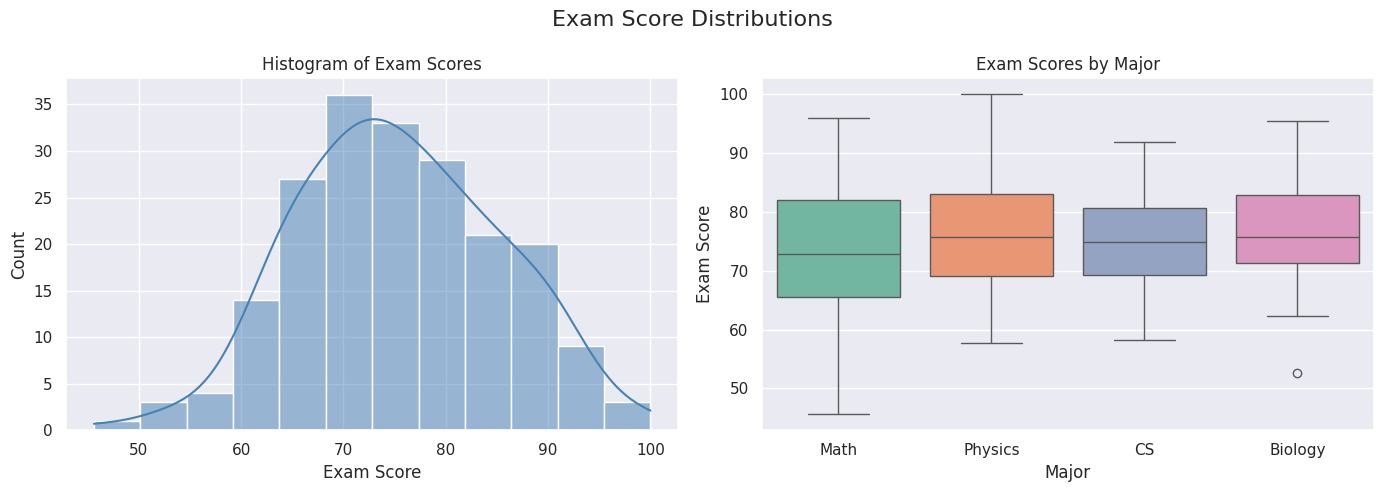

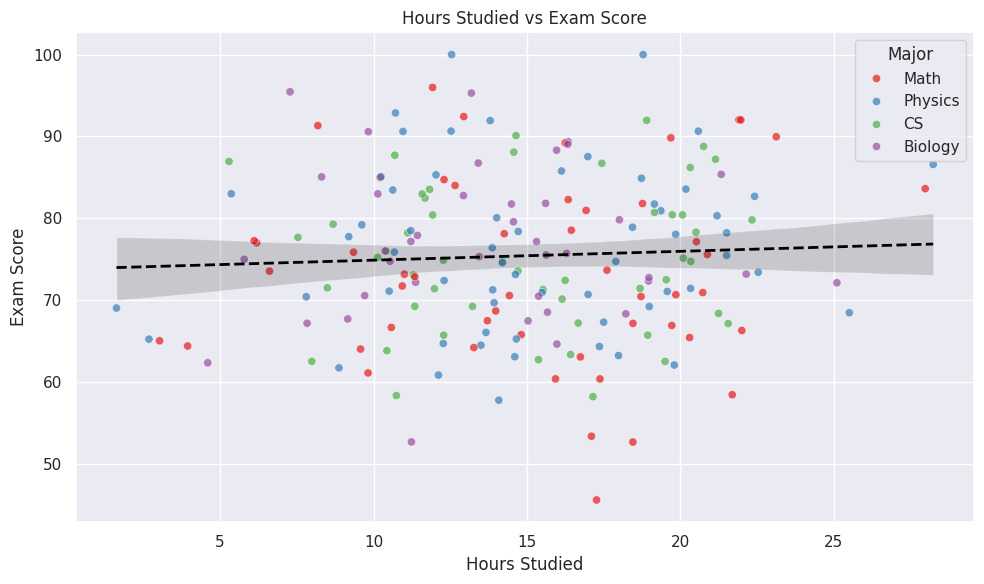

/tmp/ipykernel_3329/820159513.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.index, y=avg_scores.values, ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_3329/820159513.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='year', ax=axes[0, 1], palette='Set1')
/tmp/ipykernel_3329/820159513.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='performance', y='exam_score',


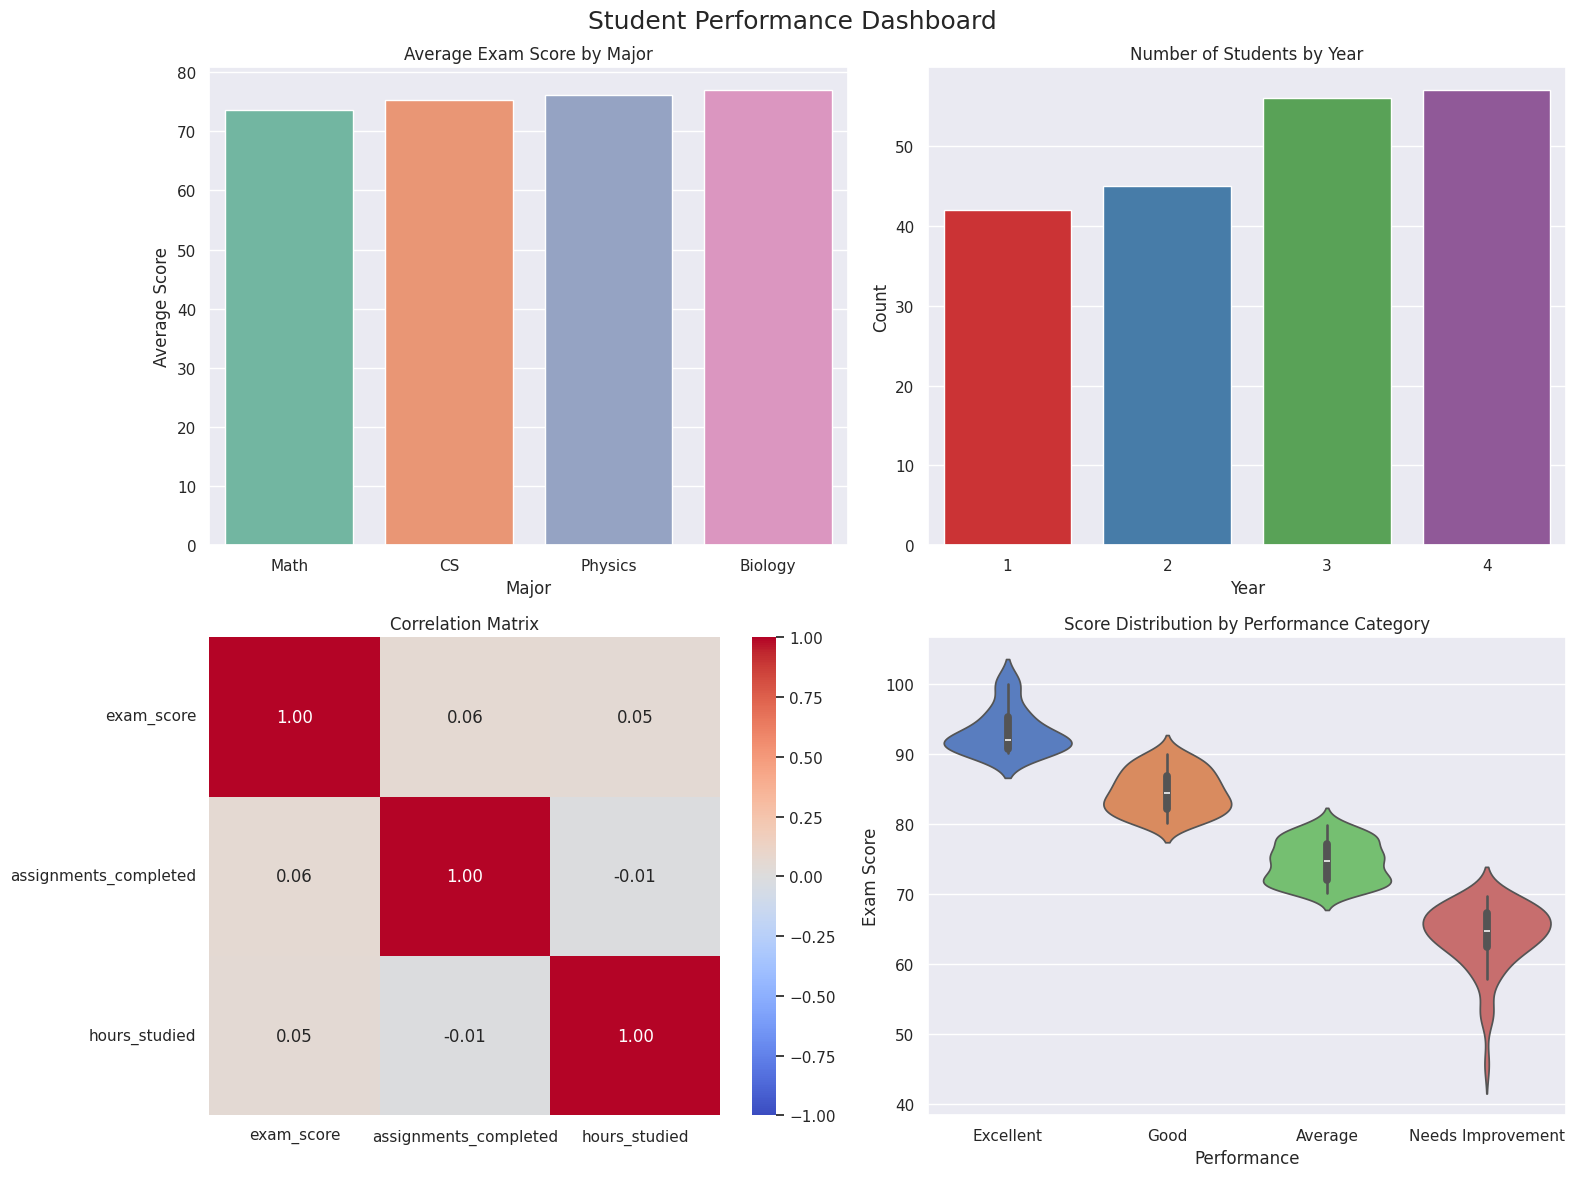

In [ ]:
# Data visualization with matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# initializing a dataset
n_students = 200
data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}
# organizing the elements of the dataset into a table
df = pd.DataFrame(data)
sns.set_theme(style="darkgrid")  # makes everything look cleaner

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Exam Score Distributions', fontsize=16)

# Plot of Histogram 
sns.histplot(df['exam_score'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Histogram of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')

# Box plot by of major by exam score
sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1], palette='Set2')
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()




plt.figure(figsize=(10, 6))

#  a scatterplot showing hours_studied on the X axis and exam_score on the y axis
sns.scatterplot(data=df, x='hours_studied', y='exam_score',
                hue='major', palette='Set1', alpha=0.7)

# a regression line showing hours_studied against exam_score
sns.regplot(data=df, x='hours_studied', y='exam_score',
            scatter=False, color='black', line_kws={'linewidth': 2, 'linestyle': '--'})

# plot details
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Student Performance Dashboard', fontsize=18)

# Bar plot of average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean().sort_values()
sns.barplot(x=avg_scores.index, y=avg_scores.values, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

# A Count plot of students per year
sns.countplot(data=df, x='year', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

# 3. a heatmap indicating the correlation matrix
num_cols = df[['exam_score', 'assignments_completed', 'hours_studied']].corr()
sns.heatmap(num_cols, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 0], vmin=-1, vmax=1)
axes[1, 0].set_title('Correlation Matrix')

df['performance'] = pd.cut(df['exam_score'],
                            bins=[0, 70, 80, 90, 100],
                            labels=['Needs Improvement', 'Average', 'Good', 'Excellent'])

# 4. A violin plot of score distribution by performance category ( A violin plot basically shows the relationship between numerical data and its probability density) [never heard of it]
order = ['Excellent', 'Good', 'Average', 'Needs Improvement']
sns.violinplot(data=df, x='performance', y='exam_score',
               order=order, ax=axes[1, 1], palette='muted')
axes[1, 1].set_title('Score Distribution by Performance Category')
axes[1, 1].set_xlabel('Performance')
axes[1, 1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

Stats by Age Group:
           num_customers  avg_income  avg_CLV  total_CLV
age_group                                               
18-25                 81    50634.02   718.37   58188.06
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

Top 10% CLV threshold: $1222.94
Number of top customers: 50
    age        income  purchase_frequency          CLV
6    38  58876.388563                  10  1287.201143
9    40  48809.492879                  10  1286.000108
19   41  21282.756976                   8  1276.279663
24   38  53981.193911                   8  1283.421714
57   64  45956.146951                   7  1343.416638
60   25  66508.326980                   7  1408.591795
76   61  62482.396341                   7  1267.760075
79   53  32054.912570                  10  1270.066217
82   65  69502.394668                  10  1371.883208
86   40  58258.629086      

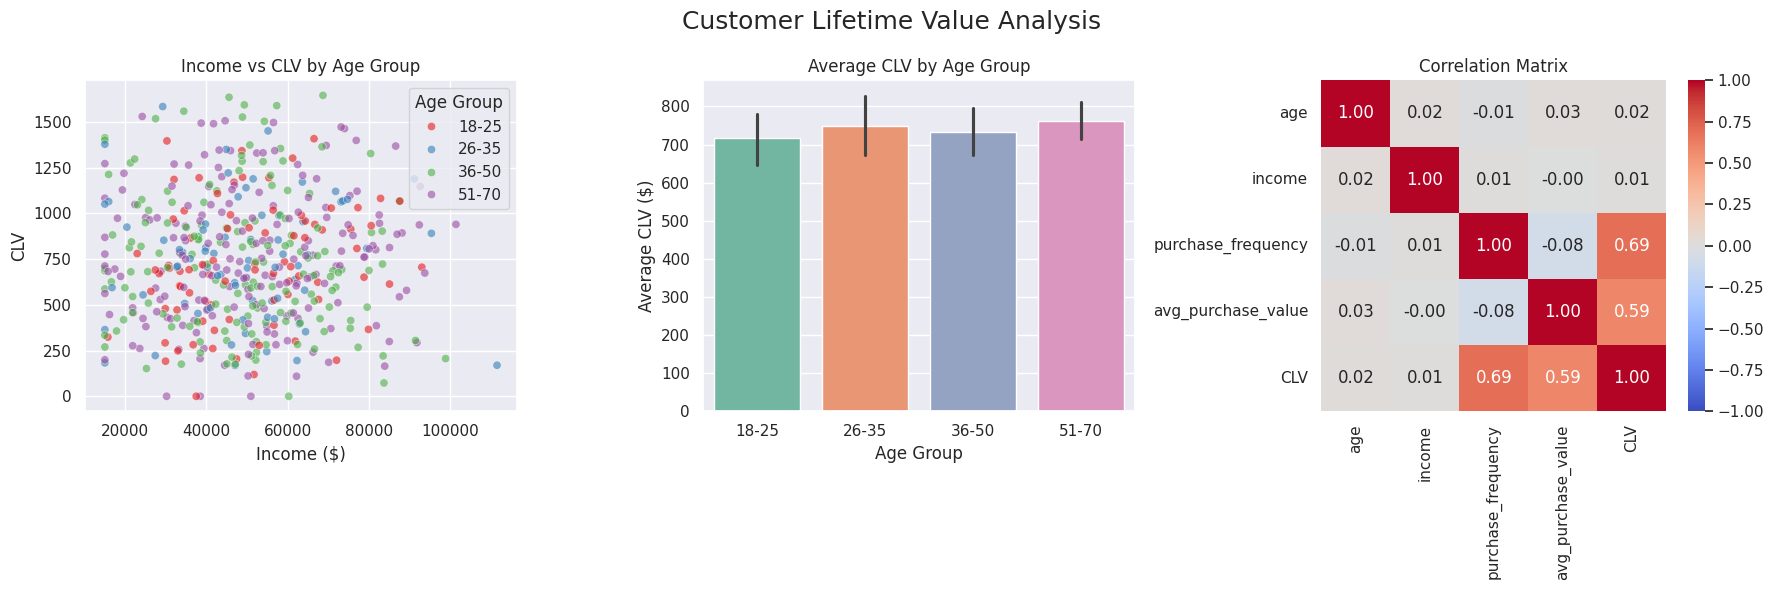

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for beautification
sns.set_theme(style="darkgrid")

# sampling a dataset 
np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# initializing a dataframe
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Calculating the Customer life value (CLV)
# CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = (customers['purchase_frequency'] *
                    customers['avg_purchase_value'] *
                    (1 + customers['churn_risk']))


customers['age_group'] = pd.cut(customers['age'],
                                 bins=[17, 25, 35, 50, 70],
                                 labels=['18-25', '26-35', '36-50', '51-70'])

# Calculating the stats per age group

age_stats = customers.groupby('age_group', observed=True).agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).round(2)

print("Stats by Age Group:")
print(age_stats)

# Calculating the top 10% Customers by CLV

threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= threshold]

print(f"\nTop 10% CLV threshold: ${threshold:.2f}")
print(f"Number of top customers: {len(top_customers)}")
print(top_customers[['age', 'income', 'purchase_frequency', 'CLV']].head(10))


# Visualizations

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Lifetime Value Analysis', fontsize=18)

# 1. Scatter plot: income vs CLV colored by age group
sns.scatterplot(data=customers, x='income', y='CLV',
                hue='age_group', palette='Set1',
                alpha=0.6, ax=axes[0])
axes[0].set_title('Income vs CLV by Age Group')
axes[0].set_xlabel('Income ($)')
axes[0].set_ylabel('CLV')
axes[0].legend(title='Age Group')

# 2. Bar chart: average CLV by age group
sns.barplot(data=customers, x='age_group', y='CLV',
            hue='age_group', legend=False,
            palette='Set2', ax=axes[1], estimator='mean')
axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV ($)')

# 3. Correlation heatmap
correlation = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2], vmin=-1, vmax=1)
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()












from my analysis, these are my takeaways and recommendations 

Frequency > Income: We looked at 500 customers, and CLV boils down to how often people buy, not how deep their pockets are. Keep them coming back, and they won't jump ship.

    The Sweet Spot: Age groups spend pretty equally, but the 36-50 crowd has the most cash to burn. They are your prime targets for higher-end pitches.

    The VIPs: The top 10% bring in a massive chunk of your cash. Lock them down immediately with serious loyalty perks.

The next plan of action: Focus retention efforts on frequent buyers across the board, and pitch premium products directly to the 36-50 bracket.
